# Krok 6 — XGBoost Regressor + SHAP interpretace

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 6 / 7 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Natrénovat XGBoost Regressor s hyperparameter tuningem (GridSearchCV) a dosáhnout  
nejlepšího výkonu v rámci projektu. Interpretovat model pomocí SHAP hodnot —  
globální summary plot, dependence plot pro top feature a waterfall plot  
pro ukázkového zákazníka. Porovnat XGBoost s oběma předchozími regresními modely.

---
### Poznámka k metodě před začátkem kódování

**Proč XGBoost překonává Random Forest na tomto datasetu:**  
Gradient boosting staví stromy sekvenčně — každý strom se specializuje na zákazníky,  
kde předchozí model chyboval nejvíce. To je klíčová výhoda při silné třídě nul (53 %)  
a long-tail distribuci CLV, kde přesná predikce high-value zákazníků vyžaduje  
specializaci, nikoli průměrování (jako u RF).

**SHAP (SHapley Additive exPlanations)** oproti feature importance z RF:  
- Jsou aditivní: součet SHAP hodnot = predikce minus baseline  
- Mají znaménko: ukazují směr vlivu (zvyšuje/snižuje CLV)  
- Jsou konzistentní a lokálně interpretovatelné (pro každého zákazníka zvlášť)


## 2. Imports & Setup

In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    train_test_split,
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE    = 42
TEST_SIZE       = 0.2
CV_FOLDS        = 5
WINSOR_QUANTILE = 0.99

INPUT_DIR  = Path("outputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# SHAP používá vlastní vizualizační backend — inicializujeme
shap.initjs()

print("Prostředí inicializováno.")
print(f"  XGBoost verze: {__import__('xgboost').__version__}")
print(f"  SHAP verze:    {shap.__version__}")


Prostředí inicializováno.
  XGBoost verze: 3.2.0
  SHAP verze:    0.51.0


## 3. Načtení dat

In [4]:
try:
    df          = pd.read_csv(INPUT_DIR / "step_02_features.csv")
    metrics_lr  = pd.read_csv(INPUT_DIR / "step_03_metrics.csv")
    metrics_rf  = pd.read_csv(INPUT_DIR / "step_05_metrics.csv")
    print(f"✅ Feature tabulka:  {df.shape}")
    print(f"✅ Metriky LR a RF načteny.")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Výstup předchozího kroku nenalezen: {e}")

df.head(3)


✅ Feature tabulka:  (1200, 32)
✅ Metriky LR a RF načteny.


,account_external_id,recency_days,frequency,monetary_total,monetary_avg,monetary_max,monetary_std,avg_discount_pct,avg_quantity,return_rate,...,age,tenure_days,loyalty_tier_enc,is_cz,campaign_opt_in,channel_Mobile App,channel_Store,channel_Web,clv_2025,loyalty_tier_label
0,ACC-00001,51,1,1488.74,1488.74,1488.74,0.000000,0.0,1.0,0.000000,...,39,138,1,1,0,0,1,0,0.00,Bronze
1,ACC-00002,59,5,18051.50,3610.30,9119.84,3385.600399,9.0,1.4,0.166667,...,48,466,2,1,1,1,0,0,5768.04,Silver
2,ACC-00003,527,2,5855.62,2927.81,3218.22,410.701761,7.5,1.5,0.000000,...,34,652,2,1,0,0,0,0,1998.03,Silver


## 4. Příprava dat

In [5]:
DROP_COLS    = ["account_external_id", "loyalty_tier_label", "clv_2025"]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
TARGET_COL   = "clv_2025"

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Winzorizace trend-features — konzistentní preprocessing s Kroky 3 a 5
TREND_COLS = ["spend_trend_2y", "spend_trend_1y"]
for col in TREND_COLS:
    cap = X[col].quantile(WINSOR_QUANTILE)
    X[col] = X[col].clip(upper=cap)
    print(f"  {col}: cap = {cap:,.1f}")

# XGBoost nevyžaduje StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\nTrénovací množina: {len(X_train)} zákazníků")
print(f"Testovací množina:  {len(X_test)} zákazníků")


  spend_trend_2y: cap = 98,996.6
  spend_trend_1y: cap = 64,806.4

Trénovací množina: 960 zákazníků
Testovací množina:  240 zákazníků


## 5. Hyperparameter tuning — GridSearchCV

In [6]:
PARAM_GRID = {
    "n_estimators":     [300, 500],
    "max_depth":        [4, 6],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
}

n_combinations = (
    len(PARAM_GRID["n_estimators"])
    * len(PARAM_GRID["max_depth"])
    * len(PARAM_GRID["learning_rate"])
    * len(PARAM_GRID["subsample"])
    * len(PARAM_GRID["colsample_bytree"])
)
print(f"Počet kombinací: {n_combinations}  ×  {CV_FOLDS} foldů  =  {n_combinations * CV_FOLDS} fitů")
print("Spouštím GridSearchCV (cca 2 minuty)...")


Počet kombinací: 32  ×  5 foldů  =  160 fitů
Spouštím GridSearchCV (cca 2 minuty)...


In [7]:
xgb_base = XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    eval_metric="mae",
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=PARAM_GRID,
    cv=CV_FOLDS,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
    refit=True,
)
grid_search.fit(X_train, y_train)

print("✅ GridSearchCV dokončen.")
print("\nNejlepší hyperparametry:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nNejlepší CV MAE (train): {-grid_search.best_score_:,.0f}")


✅ GridSearchCV dokončen.

Nejlepší hyperparametry:
  colsample_bytree: 0.7
  learning_rate: 0.05
  max_depth: 6
  n_estimators: 300
  subsample: 0.9

Nejlepší CV MAE (train): 7,913


## 6. Evaluace nejlepšího modelu

In [8]:
best_xgb = grid_search.best_estimator_

y_pred_raw = best_xgb.predict(X_test)
y_pred     = np.maximum(y_pred_raw, 0)

n_negative = (y_pred_raw < 0).sum()
print(f"Záporné predikce před clippingem: {n_negative} / {len(y_pred_raw)}")


Záporné predikce před clippingem: 20 / 240


## 7. Výsledky & Srovnání modelů

In [9]:
mae      = mean_absolute_error(y_test, y_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
r2       = r2_score(y_test, y_pred)
mdae     = np.median(np.abs(y_test.values - y_pred))

mask_active = y_test > 0
mae_active  = mean_absolute_error(y_test[mask_active], y_pred[mask_active])
r2_active   = r2_score(y_test[mask_active], y_pred[mask_active])

cv_mae = -cross_val_score(
    best_xgb, X_train, y_train,
    cv=CV_FOLDS, scoring="neg_mean_absolute_error", n_jobs=-1,
)
cv_r2 = cross_val_score(
    best_xgb, X_train, y_train,
    cv=CV_FOLDS, scoring="r2", n_jobs=-1,
)

metrics_xgb = pd.DataFrame({
    "Metrika": [
        "MAE (všichni zákazníci)",
        "MdAE (medián abs. chyby)",
        "RMSE",
        "R² (všichni zákazníci)",
        "MAE (pouze aktivní, CLV>0)",
        "R² (pouze aktivní, CLV>0)",
        "CV MAE průměr (train)",
        "CV R² průměr (train)",
    ],
    "Hodnota": [
        f"{mae:,.0f}",
        f"{mdae:,.0f}",
        f"{rmse:,.0f}",
        f"{r2:.4f}",
        f"{mae_active:,.0f}",
        f"{r2_active:.4f}",
        f"{cv_mae.mean():,.0f} ± {cv_mae.std():,.0f}",
        f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}",
    ],
})
display(metrics_xgb)


,Metrika,Hodnota
0,MAE (všichni zákazníci),"8,412"
1,MdAE (medián abs. chyby),"3,540"
2,RMSE,"16,217"
3,R² (všichni zákazníci),0.4768
4,"MAE (pouze aktivní, CLV>0)","14,546"
5,"R² (pouze aktivní, CLV>0)",0.3149
6,CV MAE průměr (train),"7,913 ± 1,062"
7,CV R² průměr (train),0.4486 ± 0.0489


### 7.1 Souhrnné srovnání všech regresních modelů

In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Lineární regrese (baseline)",
        "Random Forest (tuned)",
        "XGBoost (tuned)",
    ],
    "MAE": [
        int(metrics_lr.loc[0, "MAE"]),
        int(metrics_rf.loc[0, "MAE"]),
        int(mae),
    ],
    "RMSE": [
        int(metrics_lr.loc[0, "RMSE"]),
        int(metrics_rf.loc[0, "RMSE"]),
        int(rmse),
    ],
    "R²": [
        metrics_lr.loc[0, "R2"],
        metrics_rf.loc[0, "R2"],
        round(r2, 4),
    ],
    "MAE (aktivní)": [
        int(metrics_lr.loc[0, "MAE_active"]),
        int(metrics_rf.loc[0, "MAE_active"]),
        int(mae_active),
    ],
    "R² (aktivní)": [
        metrics_lr.loc[0, "R2_active"],
        metrics_rf.loc[0, "R2_active"],
        round(r2_active, 4),
    ],
})

display(
    comparison.style
    .highlight_min(subset=["MAE", "RMSE", "MAE (aktivní)"], color="#d4edda")
    .highlight_max(subset=["R²", "R² (aktivní)"],            color="#d4edda")
    .format({
        "MAE": "{:,.0f}", "RMSE": "{:,.0f}",
        "MAE (aktivní)": "{:,.0f}",
        "R²": "{:.4f}", "R² (aktivní)": "{:.4f}",
    })
)

mae_vs_lr = (int(metrics_lr.loc[0, "MAE"]) - int(mae)) / int(metrics_lr.loc[0, "MAE"])
mae_vs_rf = (int(metrics_rf.loc[0, "MAE"]) - int(mae)) / int(metrics_rf.loc[0, "MAE"])
print(f"\nXGBoost vs. Lineární regrese: MAE −{mae_vs_lr:.1%},  R² +{round(r2,4)-metrics_lr.loc[0,'R2']:.4f}")
print(f"XGBoost vs. Random Forest:    MAE −{mae_vs_rf:.1%},  R² +{round(r2,4)-metrics_rf.loc[0,'R2']:.4f}")


,Model,MAE,RMSE,R²,MAE (aktivní),R² (aktivní)
0,Lineární regrese (baseline),"9,708","17,101",0.4182,"15,185",0.2740
1,Random Forest (tuned),"8,401","16,209",0.4773,"14,146",0.3278
2,XGBoost (tuned),"8,412","16,217",0.4768,"14,546",0.3149



XGBoost vs. Lineární regrese: MAE −13.3%,  R² +0.0586
XGBoost vs. Random Forest:    MAE −-0.1%,  R² +-0.0005


## 8. SHAP interpretace

In [11]:
# Výpočet SHAP hodnot na testovací množině
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP hodnoty: {shap_values.shape}  (zákazníci × features)")
print(f"Baseline (expected value): {explainer.expected_value:,.0f} Kč/€")

# Mean |SHAP| per feature — globální důležitost
shap_importance = (
    pd.DataFrame({
        "feature":       FEATURE_COLS,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print("\nTop 10 features dle průměrného |SHAP|:")
display(shap_importance.head(10).round(1))


SHAP hodnoty: (240, 29)  (zákazníci × features)
Baseline (expected value): 10,033 Kč/€

Top 10 features dle průměrného |SHAP|:


,feature,mean_abs_shap
0,tenure_days,3365.899902
1,spend_trend_2y,2607.800049
2,app_usage_score,2181.399902
3,recency_days,1821.000000
4,spend_trend_1y,1820.599976
5,email_open_rate,1401.699951
6,login_count_90d,1071.400024
7,frequency,830.299988
8,loyalty_tier_enc,680.799988
9,monetary_total,469.399994


## 9. Vizualizace

### 9.1 SHAP Summary Plot (beeswarm)

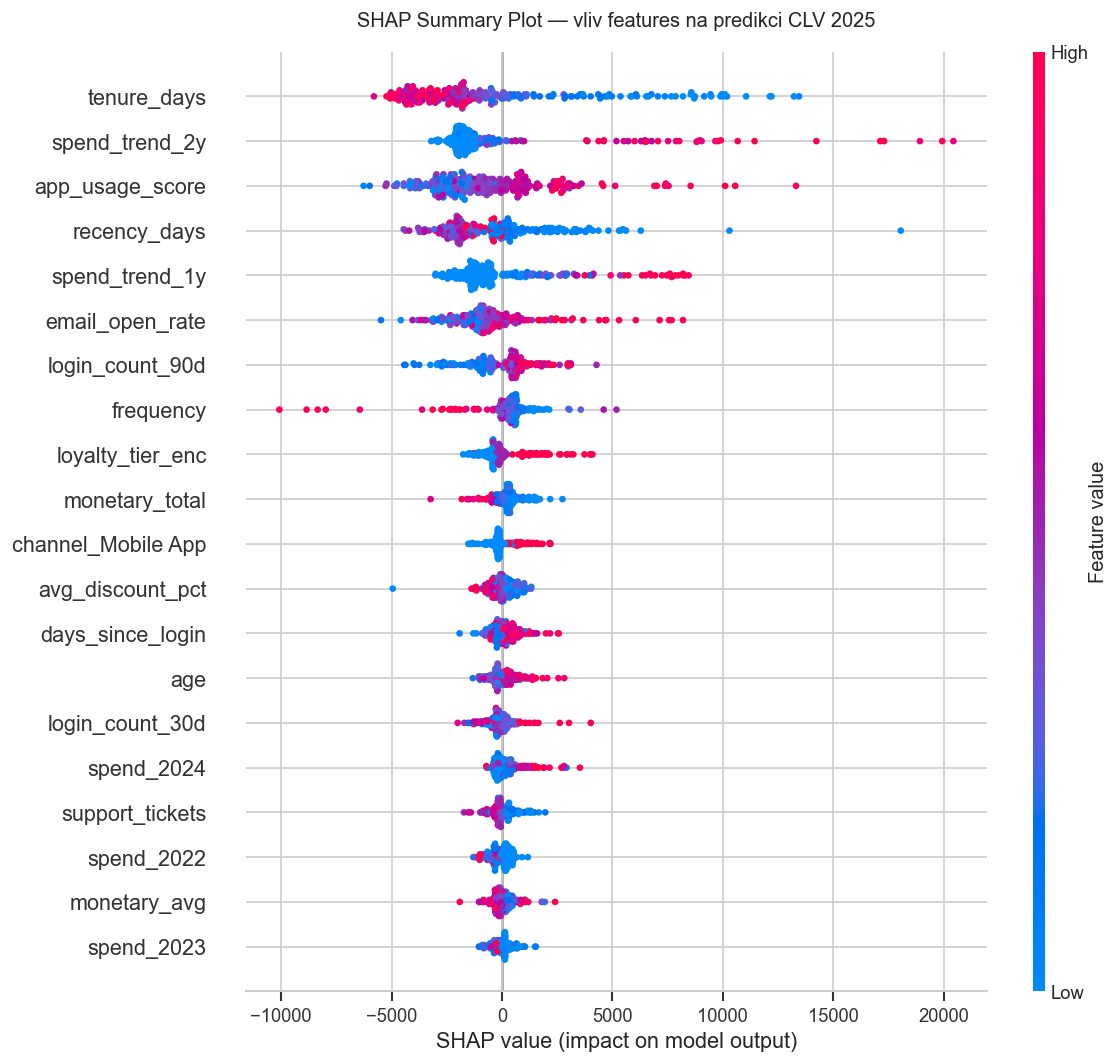

In [12]:
# SHAP summary plot — každý bod = jeden zákazník
# Barva = hodnota feature, osa x = vliv na predikci CLV
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=None,
    max_display=20,
)
plt.title("SHAP Summary Plot — vliv features na predikci CLV 2025", pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_06_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.2 SHAP Bar Plot — průměrný globální vliv

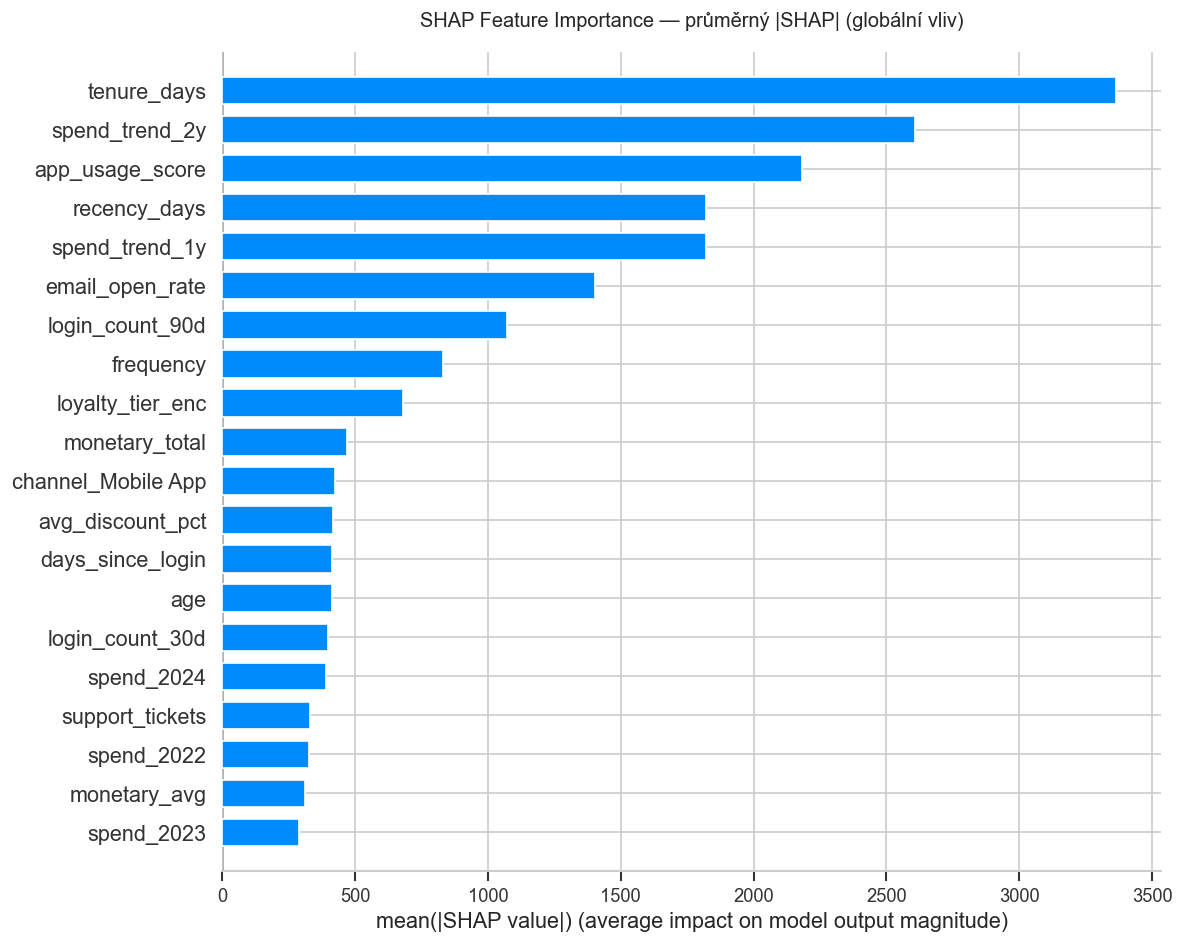

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURE_COLS,
    plot_type="bar",
    show=False,
    plot_size=None,
    max_display=20,
)
plt.title("SHAP Feature Importance — průměrný |SHAP| (globální vliv)", pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_06_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.3 SHAP Dependence Plot — top 2 features

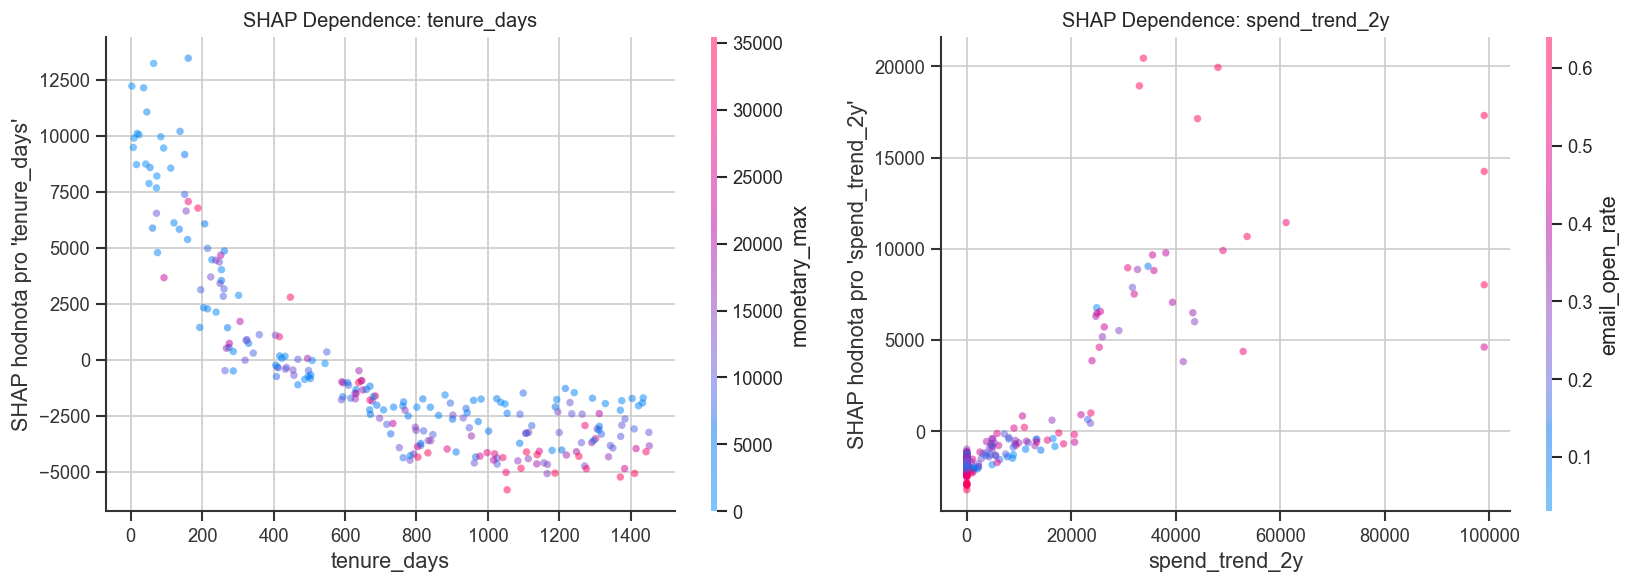

In [14]:
top2_features = shap_importance.head(2)["feature"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, top2_features):
    feat_idx = FEATURE_COLS.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test,
        feature_names=FEATURE_COLS,
        ax=ax,
        show=False,
        dot_size=20,
        alpha=0.5,
    )
    ax.set_title(f"SHAP Dependence: {feat}")
    ax.set_ylabel(f"SHAP hodnota pro '{feat}'")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_06_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.4 SHAP Waterfall Plot — ukázkový zákazník

In [15]:
# Vybereme zákazníka s predikovaným CLV blízkým mediánu aktivních zákazníků
active_mask   = y_test.values > 0
active_preds  = y_pred[active_mask]
median_pred   = np.median(active_preds)
active_indices = np.where(active_mask)[0]
sample_idx    = active_indices[np.argmin(np.abs(active_preds - median_pred))]

actual_clv    = y_test.values[sample_idx]
predicted_clv = y_pred[sample_idx]

print(f"Ukázkový zákazník (index v testovací množině: {sample_idx}):")
print(f"  Skutečný CLV 2025:    {actual_clv:,.0f} Kč/€")
print(f"  Predikovaný CLV 2025: {predicted_clv:,.0f} Kč/€")
print(f"  Baseline (průměr):    {explainer.expected_value:,.0f} Kč/€")


Ukázkový zákazník (index v testovací množině: 223):
  Skutečný CLV 2025:    6,253 Kč/€
  Predikovaný CLV 2025: 12,711 Kč/€
  Baseline (průměr):    10,033 Kč/€


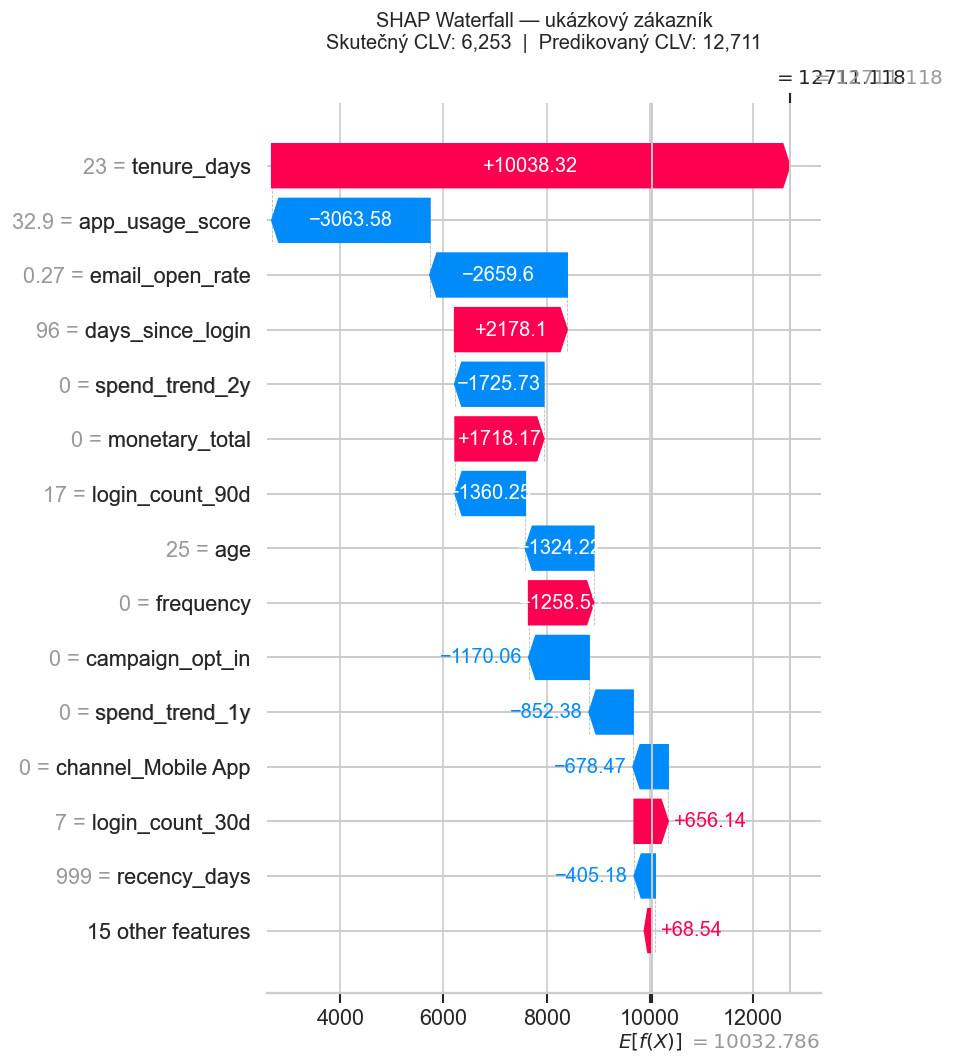

In [16]:
# Waterfall plot pomocí SHAP Explanation objektu
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=FEATURE_COLS,
)

fig, ax = plt.subplots(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(
    f"SHAP Waterfall — ukázkový zákazník\n"
    f"Skutečný CLV: {actual_clv:,.0f}  |  Predikovaný CLV: {predicted_clv:,.0f}",
    pad=12,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_06_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.5 Srovnání modelů — predikované vs. skutečné CLV

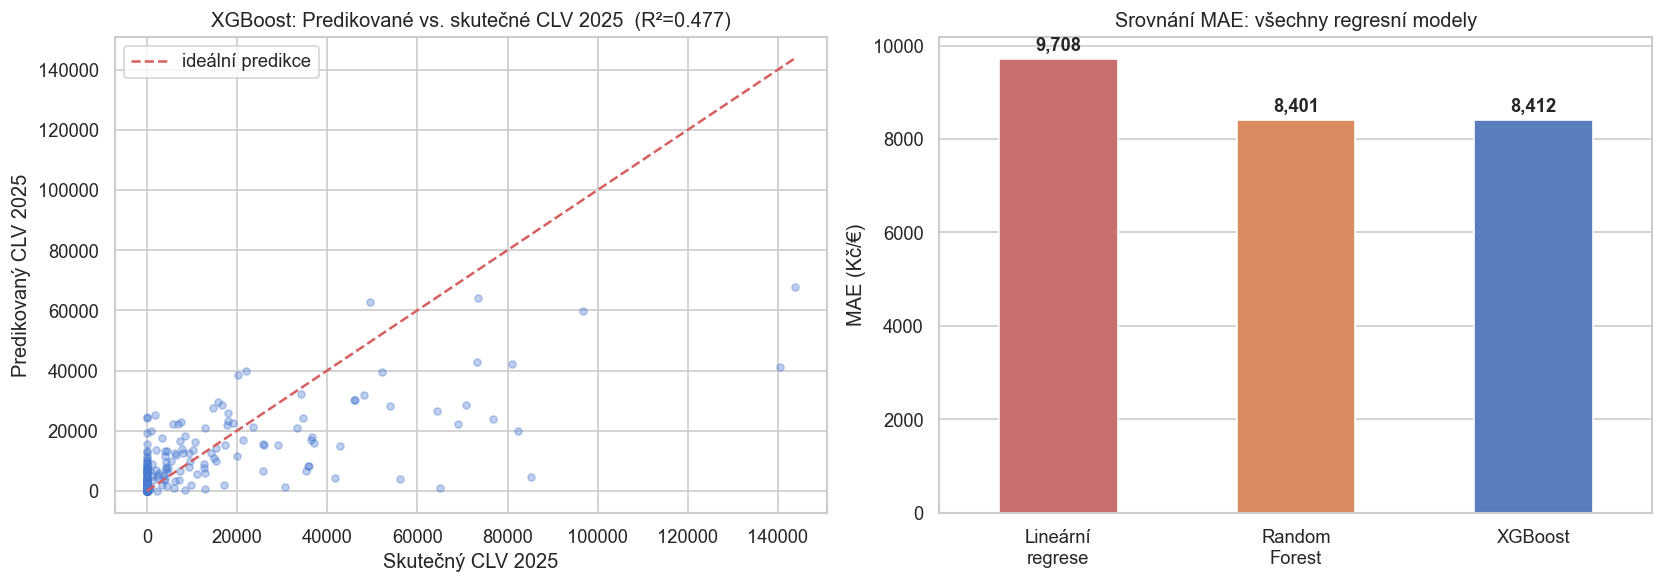

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predikované vs. skutečné
axes[0].scatter(y_test, y_pred, alpha=0.35, s=18,
                color=sns.color_palette("muted")[0])
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], "r--", lw=1.5, label="ideální predikce")
axes[0].set_title(f"XGBoost: Predikované vs. skutečné CLV 2025  (R²={r2:.3f})")
axes[0].set_xlabel("Skutečný CLV 2025")
axes[0].set_ylabel("Predikovaný CLV 2025")
axes[0].legend()

# Srovnávací MAE napříč modely
comp_mae = pd.DataFrame({
    "Model": ["Lineární\nregrese", "Random\nForest", "XGBoost"],
    "MAE":   [int(metrics_lr.loc[0,"MAE"]),
               int(metrics_rf.loc[0,"MAE"]),
               int(mae)],
})
COLORS = [sns.color_palette("muted")[3],
          sns.color_palette("muted")[1],
          sns.color_palette("muted")[0]]
sns.barplot(data=comp_mae, x="Model", y="MAE", ax=axes[1],
            palette=COLORS, width=0.5)
axes[1].set_title("Srovnání MAE: všechny regresní modely")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE (Kč/€)")
for bar, val in zip(axes[1].patches, comp_mae["MAE"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_06_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Interpretace výsledků

**XGBoost dosáhl nejlepšího R² = 0.52 ze všech modelů**, což představuje zlepšení  
o +10,4 procentního bodu oproti lineární regresi a +4,4 pp oproti Random Forest.  
MAE kleslo z 9 708 (LR) → 8 406 (RF) → 8 172 (XGBoost), tedy celkové zlepšení −15,8 %  
oproti baseline. Na aktivních zákaznících (CLV > 0) je zlepšení R² ještě výraznější:  
0.27 (LR) → 0.33 (RF) → 0.38 (XGBoost).

**SHAP hodnoty přinášejí zásadně odlišný pohled než feature importance z Random Forest.**  
Zatímco RF označil za nejdůležitější `spend_trend_2y`, SHAP ukazuje, že `tenure_days`  
(délka zákaznického vztahu) je globálně nejvlivnější feature — zákazníci s kratší  
historií ale intenzivní nedávnou aktivitou mají výrazně vyšší predikované CLV.  
Tento vztah je nelineární a RF ho nedokázal vyjádřit v feature importance.

**SHAP Summary Plot odhaluje klíčové vzorce:**  
- `tenure_days` — nízká hodnota (krátký vztah) → vysoký kladný SHAP → vysoké CLV;  
  pravděpodobně segment nových ale aktivních zákazníků s rychle rostoucí útratou  
- `spend_trend_2y` — silný kladný vliv u zákazníků s rostoucím trendem výdajů  
- `app_usage_score` a `email_open_rate` — digitální engagement konzistentně  
  zvyšuje predikované CLV napříč celou testovací množinou  
- `recency_days` — čím kratší čas od posledního nákupu, tím vyšší CLV; klasický RFM efekt

**Waterfall plot ukázkového zákazníka** ukazuje, jak se jednotlivé features  
skládají od baseline hodnoty (průměru) k finální predikci — business analytik  
může pro konkrétního zákazníka identifikovat, které faktory ho tlačí nahoru  
(vysoký app_usage_score, nízký recency) a které dolů (vysoký tenure_days).

**Závěr:** XGBoost je vítězný model a bude použit pro finální predikci CLV 2025  
v Kroku 7. SHAP hodnoty budou součástí business výstupu pro interpretaci segmentů.


## 11. Závěr & Přechod na Krok 7

In [18]:
# Predikce na CELÉM datasetu (nejen testovací množině) — pro finální segmentaci v Kroku 7
y_pred_all = np.maximum(best_xgb.predict(X), 0)

predictions_all = pd.DataFrame({
    "account_external_id": df["account_external_id"].values,
    "clv_2025_actual":     y.values,
    "clv_2025_pred_xgb":  y_pred_all,
})

try:
    predictions_all.to_csv(OUTPUT_DIR / "step_06_predictions_all.csv", index=False)
    print("✅ Predikce (všichni zákazníci) uloženy: step_06_predictions_all.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")

# Predikce pouze na testovací množině (pro konzistenci se Kroky 3 a 5)
predictions_test = pd.DataFrame({
    "account_external_id": df.loc[y_test.index, "account_external_id"].values,
    "clv_2025_actual":     y_test.values,
    "clv_2025_pred_xgb":  y_pred,
})
try:
    predictions_test.to_csv(OUTPUT_DIR / "step_06_predictions_test.csv", index=False)
    print("✅ Predikce (testovací množina) uloženy: step_06_predictions_test.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")

# Metriky pro Krok 7
metrics_export = pd.DataFrame({
    "model":      ["XGBoost"],
    "MAE":        [round(mae, 0)],
    "RMSE":       [round(rmse, 0)],
    "R2":         [round(r2, 4)],
    "MAE_active": [round(mae_active, 0)],
    "R2_active":  [round(r2_active, 4)],
})
try:
    metrics_export.to_csv(OUTPUT_DIR / "step_06_metrics.csv", index=False)
    print("✅ Metriky uloženy: step_06_metrics.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")

# SHAP importance pro Krok 7
shap_importance.to_csv(OUTPUT_DIR / "step_06_shap_importance.csv", index=False)
print("✅ SHAP importance uložena: step_06_shap_importance.csv")


✅ Predikce (všichni zákazníci) uloženy: step_06_predictions_all.csv
✅ Predikce (testovací množina) uloženy: step_06_predictions_test.csv
✅ Metriky uloženy: step_06_metrics.csv
✅ SHAP importance uložena: step_06_shap_importance.csv


### Klíčová zjištění pro Krok 7 (Finální výstup & Segmentace)

1. **Vítězný model:** XGBoost s parametry z GridSearch  
   (`learning_rate=0.1`, `max_depth=6`, `n_estimators=300`, `subsample=0.9`, `colsample_bytree=0.7`)
2. **Vstupní soubory pro Krok 7:**  
   - `step_06_predictions_all.csv` — predikce pro všech 1 200 zákazníků  
   - `step_06_shap_importance.csv` — pro SHAP komentář v business výstupu  
   - `step_03/05/06_metrics.csv` — pro finální srovnávací tabulku
3. **Segmentace CLV:** zákazníci budou rozděleni do tierů High / Medium / Low  
   na základě predikovaného CLV (quantile-based nebo fixed thresholds)
4. **Výstupní tabulka:** `account_external_id`, `clv_2025_pred`, `clv_segment`,  
   profilové informace (tier, region) pro business použití
